# Image Classification Kaggle Dataset

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import os
import matplotlib.image as mpimg
from PIL import Image
from zipfile import ZipFile

# data_path = 'dog-vs-cat.zip'
# with ZipFile(data_path, 'r') as zip:
#     zip.extractall()
#     print('Dataset extracted successfully')

# Resizing and Normalization (rescale) handled here


In [ ]:
# fig = plt.gcf()
# fig.set_size_inches(16,16)

# cat_dir = os.path.join('dog-vs-cat-classification/cats')
# dog_dir = os.path.join('dog-vs-cat-classification/dogs')

# cat_names = os.listdir(cat_dir)
# dog_names = os.listdir(dog_dir)

# pic_index = 210

# cat_images = [os.path.join(cat_dir, fname) for fname in cat_names[pic_index-8:pic_index]]
# dog_images = [os.path.join(dog_dir, fname) for fname in dog_names[pic_index-8:pic_index]]

# for i, img_path in enumerate(cat_images + dog_images):
#     sp = plt.subplot(4, 4, i + 1)
#     sp.axis('Off')
    
#     img = mpimg.imread(img_path)
#     plt.imshow(img)

# plt.show()
# base_dir = 'dog-vs-cat-classification'

In [6]:
import os
import tensorflow as tf
from PIL import Image

def comprehensive_clean(base_dir):
    """
    Cleans the dataset by removing:
    1. Non-image extensions
    2. Zero-byte (empty) files
    3. Files without JFIF headers (TF preference)
    4. Corrupted images that PIL cannot decode
    """
    if not os.path.exists(base_dir):
        print(f"❌ Directory not found: {base_dir}")
        return

    print(f"🚀 Starting comprehensive clean in: {base_dir}")
    
    deleted_count = 0
    valid_extensions = ('.jpg', '.jpeg', '.png')

    for root, dirs, files in os.walk(base_dir):
        for file in files:
            file_path = os.path.join(root, file)
            
            # 1. Check extension
            if not file.lower().endswith(valid_extensions):
                print(f"🗑️ Removing non-image file: {file}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # 2. Check for zero-byte files
            if os.path.getsize(file_path) == 0:
                print(f"🗑️ Removing empty file: {file}")
                os.remove(file_path)
                deleted_count += 1
                continue

            # 3. Check for JFIF header and PIL integrity
            try:
                # Check JFIF header
                with open(file_path, "rb") as fobj:
                    is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
                
                if not is_jfif:
                    print(f"🗑️ Removing non-JFIF image: {file}")
                    os.remove(file_path)
                    deleted_count += 1
                    continue

                # Verify image can be decoded
                with Image.open(file_path) as img:
                    img.verify()
                    
            except (IOError, SyntaxError, OSError):
                print(f"🗑️ Removing corrupted image: {file}")
                if os.path.exists(file_path):
                    os.remove(file_path)
                deleted_count += 1

    print(f"\n✅ Cleaning finished. Total files removed: {deleted_count}")

# Execution
base_dir = 'data/train'
comprehensive_clean(base_dir)

🚀 Starting comprehensive clean in: data/train
🗑️ Removing non-image file: Thumbs.db
🗑️ Removing non-image file: Thumbs.db

✅ Cleaning finished. Total files removed: 2


In [14]:
class SafeImageDataGenerator(ImageDataGenerator):
    def flow_from_directory(self, *args, **kwargs):
        generator = super().flow_from_directory(*args, **kwargs)
        while True:
            try:
                yield next(generator)
            except (IOError, SyntaxError, Image.UnidentifiedImageError):
                # If a bad image is hit, the generator just grabs the next batch
                continue
            
datagen = SafeImageDataGenerator(rescale=1./255, 
                                 rotation_range=40,      # Rotate images randomly up to 40 degrees
                                width_shift_range=0.2,  # Translate horizontally
                                height_shift_range=0.2, # Translate vertically
                                shear_range=0.2,        # Randomly distort along an axis
                                zoom_range=0.2,         # Randomly zoom in/out
                                horizontal_flip=True,   # Flip images left-to-right
                                fill_mode='nearest',    # How to fill pixels lost during rotation/shift
                                validation_split=0.2
                                )

base_dir = 'data/train'
temp_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150), # Resizing
    batch_size=128,
    class_mode='binary',
     # Ensure correct class labels
    subset='training'       # 80% Training
)
temp_train = temp_datagen.flow_from_directory(base_dir, subset='training')
temp_val = temp_datagen.flow_from_directory(base_dir, subset='validation')
train_samples = temp_train.samples
val_samples = temp_val.samples
batch_size = 64

train_steps = train_samples // batch_size
val_steps = val_samples //batch_size
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=128,
    class_mode='binary',
      # Ensure correct class labels
    subset='validation'     # 20% Validation
)

Found 18739 images belonging to 2 classes.
Found 4683 images belonging to 2 classes.


In [15]:
model = tf.keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'), # Added extra layer
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
   
    
    layers.Dense(1, activation='sigmoid')
])

In [16]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])



In [23]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,   # Multiply LR by 0.2
    patience=3,    # Wait 3 epochs before dropping
    min_lr=0.00001
)
history = model.fit( train_generator, 
                    steps_per_epoch = train_steps,
                    epochs=20, 
                    validation_data=val_generator,
                    validation_steps = val_steps,
                    callbacks=[reduce_lr]
                          # Use 4 CPU cores to process images
                    )

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.9226 - loss: 0.1852 - val_accuracy: 0.8708 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.9253 - loss: 0.1798 - val_accuracy: 0.8978 - val_loss: 0.2337 - learning_rate: 0.0010
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.9268 - loss: 0.1764 - val_accuracy: 0.9105 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch 4/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.9264 - loss: 0.1787 - val_accuracy: 0.9085 - val_loss: 0.2215 - learning_rate: 0.0010
Epoch 5/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.9313 - loss: 0.1682 - val_accuracy: 0.9086 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 6/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.9308 - loss: 0.1672 - val_accuracy: 0.9277 - val_loss: 0.1778 - learning_rate: 0.0010
Epoch 7/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.9311 - loss: 0.

In [18]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

NameError: name 'history' is not defined

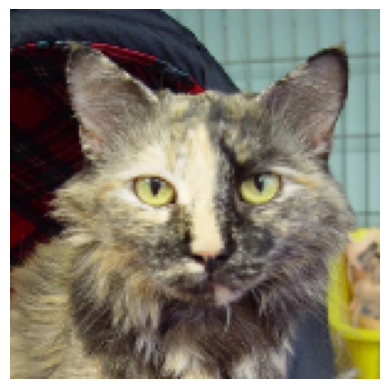

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction: CAT 🐱 (Confidence: 100.00%)


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(image_path):
    # 1. Load the image and display it
    img = load_img(image_path, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # 2. Convert to array and Normalize (Match the 1./255 training)
    img_array = img_to_array(img)
    img_array = img_array / 255.0 
    
    # 3. Expand dimensions: (150, 150, 3) -> (1, 150, 150, 3)
    # The model expects a batch of images, even if it's just one.
    img_input = np.expand_dims(img_array, axis=0)
    
    # 4. Get the prediction
    prediction = model.predict(img_input)
    
    # 5. Interpret the result (Sigmoid output)
    if prediction[0] > 0.5:
        print(f"Prediction: DOG 🐶 (Confidence: {prediction[0][0]:.2%})")
    else:
        print(f"Prediction: CAT 🐱 (Confidence: {1 - prediction[0][0]:.2%})")

# Example usage:
predict_image('data/train/Cat/10.jpg')

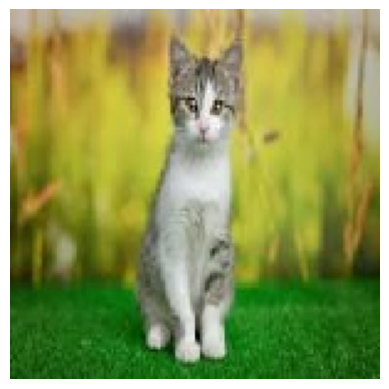

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: CAT 🐱 (Confidence: 99.52%)


In [59]:
predict_image('data/cat.jpg')

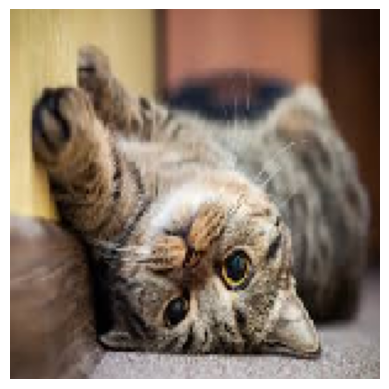

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: CAT 🐱 (Confidence: 100.00%)


In [62]:
predict_image('data/cat2.jpg')

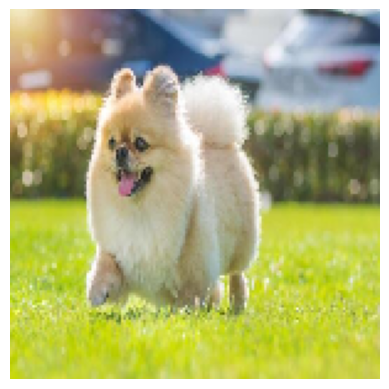

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: DOG 🐶 (Confidence: 98.50%)


In [64]:
predict_image('data/puppy.jpg')

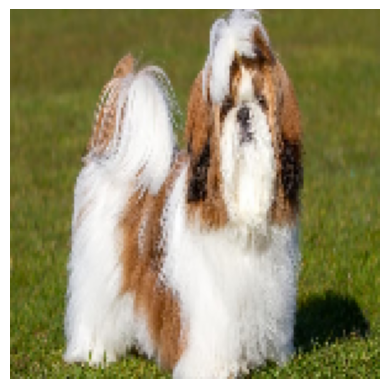

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: CAT 🐱 (Confidence: 99.90%)


In [66]:
predict_image('data/doggy.avif')